<a href="https://colab.research.google.com/github/GloryValentio/klasifikasi_jenis_lesi_kulit/blob/main/klasifikasi_jenis_lesi_kulit_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Urutan pengerjaan yang benar adalah:

EDA → Mapping Path → Encoding Label → Split Data → Data Augmentation → Generator → EfficientNetB1 → Training → Evaluasi → F1 Score → Confusion Matrix.

# Import Library & Konfigurasi Global

In [ ]:
import tensorflow as tf
import os
import random
from sklearn.metrics import f1_score
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB2
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import Precision, Recall
import numpy as np
from io import BytesIO
# Plotting and dealing with images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# from ipywidgets import widgets
from PIL import Image

In [ ]:
DATA_DIR = "/content/drive/MyDrive/take_homecnn"
PART1_DIR = os.path.join(DATA_DIR, "/content/drive/MyDrive/take_homecnn/HAM10000_images_part_1")
PART2_DIR = os.path.join(DATA_DIR, "/content/drive/MyDrive/take_homecnn/HAM10000_images_part_2")
METADATA_PATH = os.path.join(DATA_DIR, "/content/drive/MyDrive/take_homecnn/HAM10000_metadata.csv")

#globa konfigurasi
IMG_SIZE = 192
BATCH_SIZE = 32
EPOCHS = 30
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Eksplorasi Data Analisi (EDA)

In [ ]:
#Import Library
import pandas as pd
import numpy as np

# Baca meta data
df = pd.read_csv(METADATA_PATH)

print(df.head())
print(df.shape)

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
(10015, 7)


In [ ]:
# Melihat distribusi kelas
class_distribution = df['dx'].value_counts()

print(class_distribution)

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


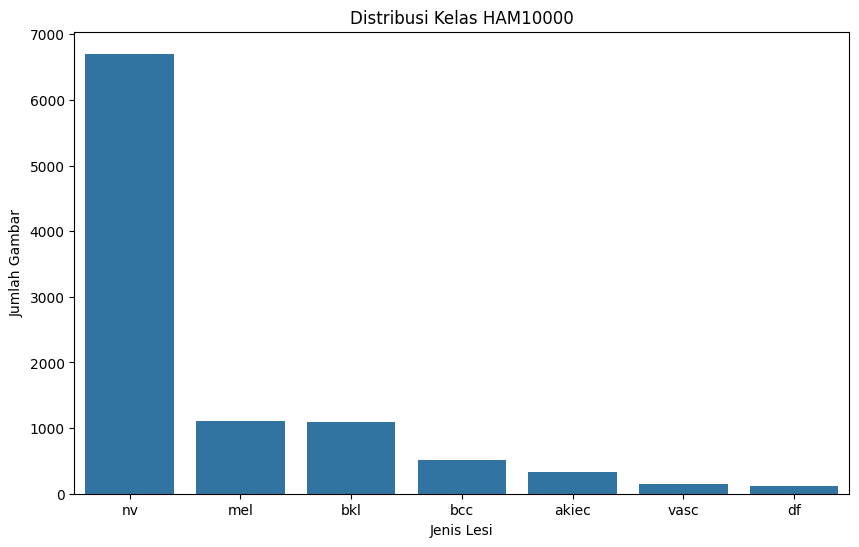

In [ ]:
#Visualisasi
import seaborn as sns
plt.figure(figsize=(10,6))

sns.barplot(
    x=class_distribution.index,
    y=class_distribution.values
)

plt.title("Distribusi Kelas HAM10000")
plt.xlabel("Jenis Lesi")
plt.ylabel("Jumlah Gambar")

plt.show()

# Membuat Mapping Path Gambar


In [ ]:
# Gabungkan gambar dari part 1 dan part 2
image_paths = {}

for img in os.listdir(PART1_DIR):
    image_id = img.split(".")[0]
    image_paths[image_id] = os.path.join(PART1_DIR, img)

for img in os.listdir(PART2_DIR):
    image_id = img.split(".")[0]
    image_paths[image_id] = os.path.join(PART2_DIR, img)

In [ ]:
# Tambahkan path ke dataframe:
df["path"] = df["image_id"].map(image_paths.get)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/take_homecnn/HAM10000_i...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/take_homecnn/HAM10000_i...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/take_homecnn/HAM10000_i...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/take_homecnn/HAM10000_i...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/take_homecnn/HAM10000_i...


In [ ]:
# Cek apakah ada path yang kosong:
print(df["path"].isnull().sum())

0


# Encoding Label
| Kode  | Penyakit             |
| ----- | -------------------- |
| akiec | Actinic Keratoses    |
| bcc   | Basal Cell Carcinoma |
| bkl   | Benign Keratosis     |
| df    | Dermatofibroma       |
| mel   | Melanoma             |
| nv    | Melanocytic Nevi     |
| vasc  | Vascular Lesions     |


In [ ]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["label"] = le.fit_transform(df["dx"])

print(le.classes_)

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


# Split Data

In [ ]:
from sklearn.model_selection import train_test_split
#Train and test
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

# Train and Validation
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=SEED
)

#Jumlah data
print("Train :", len(train_df))
print("Val   :", len(val_df))
print("Test  :", len(test_df))

Train : 6409
Val   : 1603
Test  : 2003


In [ ]:
#Class weight
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Ambil seluruh nilai label numerik dari dataframe training Anda
train_labels = train_df["label"].values

# 2. Ambil daftar kelas unik yang ada (0 sampai 6)
classes = np.unique(train_labels)

# 3. Hitung bobotnya dengan strategi 'balanced'
# Strategi ini otomatis memberikan bobot besar untuk kelas yang jumlah datanya sedikit
calculated_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)

# 4. Ubah hasilnya menjadi format Dictionary (Format yang diwajibkan oleh Keras)
class_weight_dict = dict(zip(classes, calculated_weights))

# 5. Tampilkan hasilnya untuk pengecekan Anda
print("--- Bobot Kelas Otomatis Berhasil Dihitung ---")
for cls, weight in class_weight_dict.items():
    # Menggunakan le.inverse_transform untuk memetakan kembali angka ke teks asli penyakitnya (akiec, nv, dll)
    class_name = le.inverse_transform([cls])[0]
    print(f"Kelas {cls} ({class_name}): {weight:.4f}")

--- Bobot Kelas Otomatis Berhasil Dihitung ---
Kelas 0 (akiec): 4.3807
Kelas 1 (bcc): 2.7829
Kelas 2 (bkl): 1.3024
Kelas 3 (df): 12.3726
Kelas 4 (mel): 1.2859
Kelas 5 (nv): 0.2134
Kelas 6 (vasc): 10.0612


# Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest')

val_test_datagen = ImageDataGenerator()

# Data Generator

In [ ]:
#train
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="label",

    target_size=(IMG_SIZE, IMG_SIZE),

    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=True
)

#validation
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="label",

    target_size=(IMG_SIZE, IMG_SIZE),

    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=False
)

#Testing
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="label",

    target_size=(IMG_SIZE, IMG_SIZE),

    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 6409 validated image filenames.
Found 1603 validated image filenames.
Found 2003 validated image filenames.


# Transfer Learning EfficientNetB2

In [ ]:
base_model = EfficientNetB2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze
base_model.trainable = False

In [ ]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation='relu')(x)


outputs = layers.Dense(7,activation='softmax')(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 6, 6, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       180,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,949,824 (30.33 MB)

 Trainable params: 181,255 (708.03 KB)

 Non-trainable params: 7,768,569 (29.63 MB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# Callback

In [ ]:
#Callback untuk 1
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

# callback 2
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,       # Tunggu 5 epoch. Jika tak membaik juga, hentikan training!
    verbose=1,
    restore_best_weights=True # Fitur ajaib: Otomatis mengembalikan bobot terbaik, bukan bobot di epoch terakhir yang jelek.
)

# Training

In [ ]:
darhistory = model.fit(
    train_generator,

    validation_data=val_generator,

    epochs=EPOCHS,

    callbacks=[
        reduce_lr
    ]
)

Epoch 1/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 1635s 8s/step - accuracy: 0.6962 - loss: 0.8808 - val_accuracy: 0.7187 - val_loss: 0.7507 - learning_rate: 0.0010
Epoch 2/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 720s 4s/step - accuracy: 0.7344 - loss: 0.7433 - val_accuracy: 0.7305 - val_loss: 0.7192 - learning_rate: 0.0010
Epoch 3/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 709s 4s/step - accuracy: 0.7372 - loss: 0.7127 - val_accuracy: 0.7286 - val_loss: 0.6993 - learning_rate: 0.0010
Epoch 4/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 720s 4s/step - accuracy: 0.7454 - loss: 0.6892 - val_accuracy: 0.7424 - val_loss: 0.6757 - learning_rate: 0.0010
Epoch 5/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 714s 4s/step - accuracy: 0.7550 - loss: 0.6708 - val_accuracy: 0.7492 - val_loss: 0.6756 - learning_rate: 0.0010
Epoch 6/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7597 - loss: 0.6563
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
201/201 ━━━━━━━━━━━━━━━━━━━━ 723s 4s/step - accuracy: 0.7558 - loss: 0.66

# Plot Accuracy & Plot loss

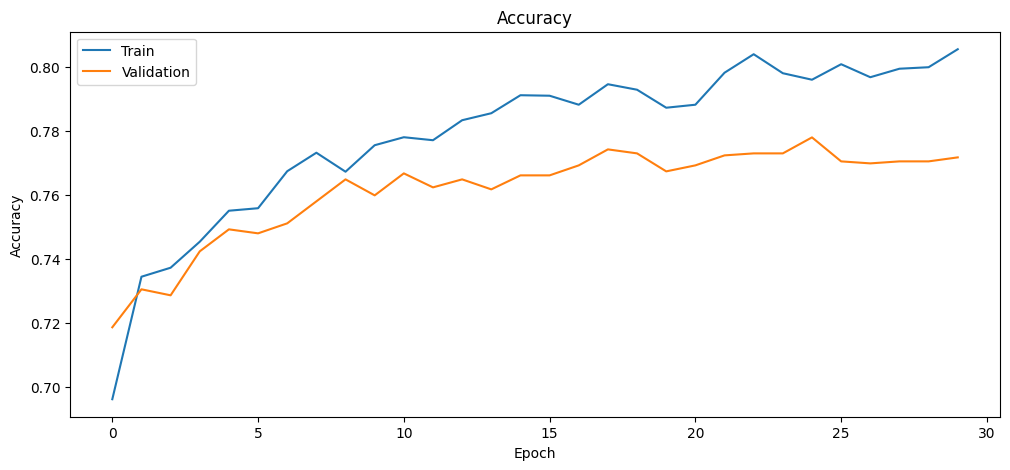

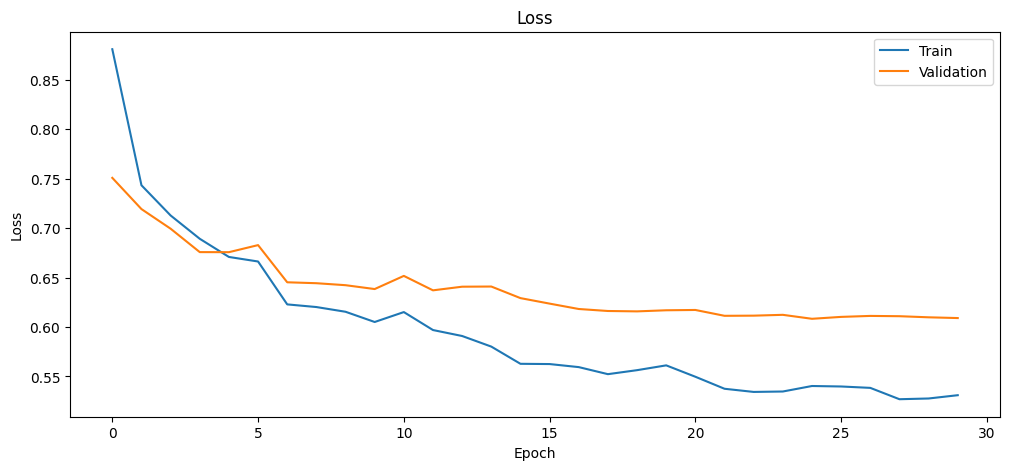

In [ ]:
import matplotlib.pyplot as plt

#Accuracy
plt.figure(figsize=(12,5))

plt.plot(darhistory.history['accuracy'])
plt.plot(darhistory.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Train',
    'Validation'
])

plt.show()

#Loss
plt.figure(figsize=(12,5))

plt.plot(darhistory.history['loss'])
plt.plot(darhistory.history['val_loss'])

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Train',
    'Validation'
])

plt.show()

#Evaluasi Test Set

In [ ]:
results = model.evaluate(test_generator)

print(results)

63/63 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.7808 - loss: 0.5962
[0.5962030291557312, 0.7808287739753723]


# Prediksi dan F1-Score

In [ ]:
pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)

y_true = test_df["label"].values

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("F1 Score :", f1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step
F1 Score : 0.7620082703285835


# Confusion Matrix

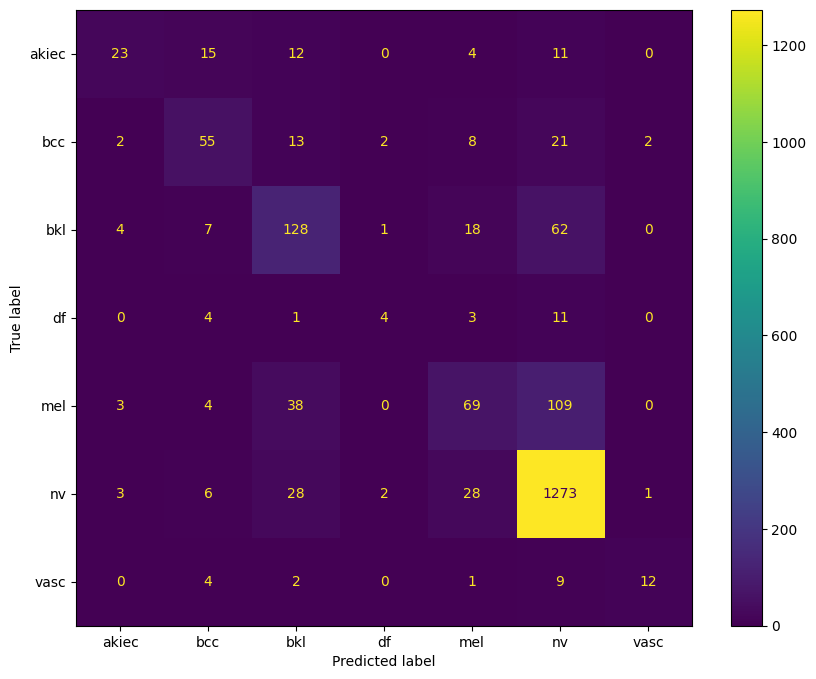

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(
    figsize=(10,8)
)

disp.plot(ax=ax)

plt.show()

In [ ]:
# # Misal kita batasi kelas 'nv' maksimal 1000 gambar saja di data training
# nv_data = train_df[train_df['label'] == 5] # Asumsi 5 adalah kode le.classes_ untuk 'nv'
# other_data = train_df[train_df['label'] != 5]

# # Ambil 1000 sampel acak dari nv
# nv_undersampled = nv_data.sample(n=1000, random_state=SEED)

# # Gabungkan kembali
# train_df_balanced = pd.concat([nv_undersampled, other_data])

# # Acak urutannya agar tidak menumpuk
# train_df_balanced = train_df_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

# # Gunakan train_df_balanced ini ke dalam train_generator Anda